# 04 — Финальный Pipeline

In [2]:
%%capture
!pip install -q ultralytics easyocr torch torchvision Pillow matplotlib seaborn pandas opencv-python-headless lap pillow-heif

In [3]:
import re, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import resnet18
from PIL import Image, ImageDraw, ImageFont
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import easyocr
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    from google.colab import output as _colab_out; IN_COLAB = True
    from google.colab.patches import cv2_imshow
except ImportError:
    IN_COLAB = False
    def cv2_imshow(img): plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

COLOR_LABELS = ['black','white','silver','red','blue','yellow','green','brown','orange']
BODY_LABELS  = ['hatchback','minibus','sedan','suv','truck','van']

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/diploma')
    DRIVE_MODELS = DRIVE_ROOT / 'models'
    INFER_DIR    = DRIVE_ROOT / 'inference'
else:
    DRIVE_MODELS = Path('diploma_models')
    INFER_DIR    = Path('inference')
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
INFER_DIR.mkdir(parents=True, exist_ok=True)

VEHICLE_MODEL_PATH = 'yolo26n.pt'
PLATES_MODEL_PATH  = DRIVE_MODELS / 'yolo26n_plates.pt'
_choice_path = DRIVE_MODELS / 'detector_choice.json'
if _choice_path.exists():
    import json as _json_choice
    with open(_choice_path) as _f:
        _choice = _json_choice.load(_f)
    VEHICLE_MODEL_PATH = _choice.get('vehicle_model', VEHICLE_MODEL_PATH)
    PLATES_MODEL_PATH  = Path(_choice.get('plates_model', str(PLATES_MODEL_PATH)))
    print('Детектор-победитель из nb01:', _choice.get('winner', '?'))
COLOR_MODEL_PATH   = DRIVE_MODELS / 'color_resnet18.pth'
BODY_MODEL_PATH    = DRIVE_MODELS / 'body_resnet18.pth'

OUTPUT_DIR = Path('diploma_04_pipeline/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


PLATE_REGEX = re.compile(r'[АВЕКМНОРСТУХ]\d{3}[АВЕКМНОРСТУХ]{2}\d{2,3}')
LATIN_TO_CYR = str.maketrans('ABEKMHOPCTYX', 'АВЕКМНОРСТУХ')
VEHICLE_CLASSES = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}

INF_TF = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

_FONT_PATHS = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
    '/usr/share/fonts/TTF/DejaVuSans.ttf',
]
_LABEL_FONT = None
for _fp in _FONT_PATHS:
    try:
        _LABEL_FONT = ImageFont.truetype(_fp, 15)
        break
    except OSError:
        pass
if _LABEL_FONT is None:
    _LABEL_FONT = ImageFont.load_default()

print(f'Device: {DEVICE}  |  Font: {_LABEL_FONT}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Детектор-победитель из nb01: YOLO26n
Device: cuda  |  Font: <PIL.ImageFont.FreeTypeFont object at 0x7abbfe0235c0>


## Загрузка моделей из предыдущих ноутбуков

In [4]:
vehicle_model = YOLO(VEHICLE_MODEL_PATH)
print(f'vehicle_model  OK')

if PLATES_MODEL_PATH.exists():
    plate_model = YOLO(str(PLATES_MODEL_PATH))
    print(f'plate_model    OK  ({PLATES_MODEL_PATH})')
else:
    plate_model = None
    print(f'plate_model    НЕ НАЙДЕНА: {PLATES_MODEL_PATH}')
    print('  → Скопируйте yolo26n_plates.pt из Google Drive (ноутбук 01)')

color_model = resnet18(weights=None)
color_model.fc = nn.Linear(color_model.fc.in_features, len(COLOR_LABELS))
if COLOR_MODEL_PATH.exists():
    color_model.load_state_dict(torch.load(COLOR_MODEL_PATH, map_location=DEVICE))
    print(f'color_model    OK  ({COLOR_MODEL_PATH})')
else:
    print(f'color_model    НЕ НАЙДЕНА: {COLOR_MODEL_PATH}')
    print('  → Скопируйте color_resnet18.pth из Google Drive (ноутбук 02)')
color_model = color_model.to(DEVICE).eval()

body_model = resnet18(weights=None)
body_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(body_model.fc.in_features, len(BODY_LABELS)),
)
if BODY_MODEL_PATH.exists():
    body_model.load_state_dict(torch.load(BODY_MODEL_PATH, map_location=DEVICE))
    print(f'body_model     OK  ({BODY_MODEL_PATH})')
else:
    print(f'body_model     НЕ НАЙДЕНА: {BODY_MODEL_PATH}')
    print('  → Скопируйте body_resnet18.pth из Google Drive (ноутбук 03)')
body_model = body_model.to(DEVICE).eval()

print('Загрузка EasyOCR...')
ocr_reader = easyocr.Reader(['ru', 'en'], gpu=(DEVICE=='cuda'))
print('ocr_reader     OK')

vehicle_model  OK
plate_model    OK  (/content/drive/MyDrive/diploma/models/yolo26n_plates.pt)
color_model    OK  (/content/drive/MyDrive/diploma/models/color_resnet18.pth)


body_model     OK  (/content/drive/MyDrive/diploma/models/body_resnet18.pth)
Загрузка EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Completeocr_reader     OK


## Определение хелпер-функций

In [5]:
def classify(model, labels, img_crop_bgr):
    """Классификация обрезанного фрагмента изображения."""
    img_pil = Image.fromarray(cv2.cvtColor(img_crop_bgr, cv2.COLOR_BGR2RGB))
    with torch.no_grad():
        probs = torch.softmax(model(INF_TF(img_pil).unsqueeze(0).to(DEVICE)), dim=1)
    idx = int(probs.argmax())
    return labels[idx], round(float(probs[0][idx]), 3)

def detect_plate(vehicle_crop, plate_model):
    """Найти рамку номера внутри кропа ТС."""
    if plate_model is None:
        return None
    results = plate_model(vehicle_crop, verbose=False, conf=0.25)
    boxes   = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    box = boxes.xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = max(0, box[0]), max(0, box[1]), box[2], box[3]
    return vehicle_crop[y1:y2, x1:x2] if (x2 > x1 and y2 > y1) else None

_PLATE_ALLOWLIST = 'АВЕКМНОРСТУХABEKMHOPCTYX0123456789'

def read_plate_ocr(plate_crop, reader):
    if plate_crop is None or plate_crop.size == 0:
        return ''

    h, w = plate_crop.shape[:2]
    scale = max(1, 300 // max(w, 1))
    if scale > 1:
        plate_crop = cv2.resize(plate_crop, (w * scale, h * scale),
                                interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    _, gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    result = reader.readtext(gray, detail=1, allowlist=_PLATE_ALLOWLIST)
    result.sort(key=lambda r: (r[0][0][0] + r[0][2][0]) / 2)
    text = ''.join([r[1] for r in result]).upper().replace(' ', '').translate(LATIN_TO_CYR)
    m = PLATE_REGEX.search(text)
    return m.group(0) if m else text[:9]

_FONT_CACHE = {}
def _get_font(size):
    if size not in _FONT_CACHE:
        f = None
        for fp in _FONT_PATHS:
            try:
                f = ImageFont.truetype(fp, size); break
            except OSError:
                pass
        _FONT_CACHE[size] = f or ImageFont.load_default()
    return _FONT_CACHE[size]

def box_thickness(w_img):
    return max(2, round(w_img / 640))

def _draw_label_pil(canvas_bgr, x1, y1, label):
    w_img     = canvas_bgr.shape[1]
    font_size = max(15, round(w_img / 80))
    font      = _get_font(font_size)
    pad       = max(3, font_size // 4)
    pil_img   = Image.fromarray(cv2.cvtColor(canvas_bgr, cv2.COLOR_BGR2RGB))
    draw      = ImageDraw.Draw(pil_img)
    bbox_t    = draw.textbbox((0, 0), label, font=font)
    tw, th    = bbox_t[2] - bbox_t[0], bbox_t[3] - bbox_t[1]
    y_top     = max(0, y1 - th - 2 * pad)
    draw.rectangle([(x1, y_top), (x1 + tw + 2 * pad, y1)], fill=(0, 200, 0))
    draw.text((x1 + pad, y_top + pad), label, fill=(0, 0, 0), font=font)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def process_frame(frame_bgr):
    det_results = vehicle_model(frame_bgr, verbose=False, conf=0.4, classes=list(VEHICLE_CLASSES))
    boxes       = det_results[0].boxes
    vehicles    = []
    if boxes is None:
        return frame_bgr, vehicles
    canvas = frame_bgr.copy()
    thick  = box_thickness(frame_bgr.shape[1])
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        cls_id          = int(box.cls[0])
        crop            = frame_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        color_lbl, color_conf = classify(color_model, COLOR_LABELS, crop)
        body_lbl,  body_conf  = classify(body_model,  BODY_LABELS,  crop)
        plate_crop = detect_plate(crop, plate_model)
        plate_text = read_plate_ocr(plate_crop, ocr_reader)
        vehicles.append({
            'bbox': [x1, y1, x2, y2], 'class': VEHICLE_CLASSES.get(cls_id, 'vehicle'),
            'color': color_lbl, 'color_conf': color_conf,
            'body':  body_lbl,  'body_conf':  body_conf,
            'plate': plate_text,
        })
        label  = f'{color_lbl} {body_lbl} {plate_text}'
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 200, 0), thick)
        canvas = _draw_label_pil(canvas, x1, y1, label)
    return canvas, vehicles


## Тест на изображении

Изображения в папке: ['IMG_1243.HEIC', 'IMG_8429.HEIC', 'IMG_8460.HEIC', 'IMG_8461.HEIC', 'IMG_8462.HEIC', 'inf3.jpg', 'rr.jpg', 'santafe.jpeg']
Выбрано: /content/drive/MyDrive/diploma/inference/santafe.jpeg
Найдено объектов: 1
  truck       цвет=white (0.92)  кузов=suv (0.42)  номер=


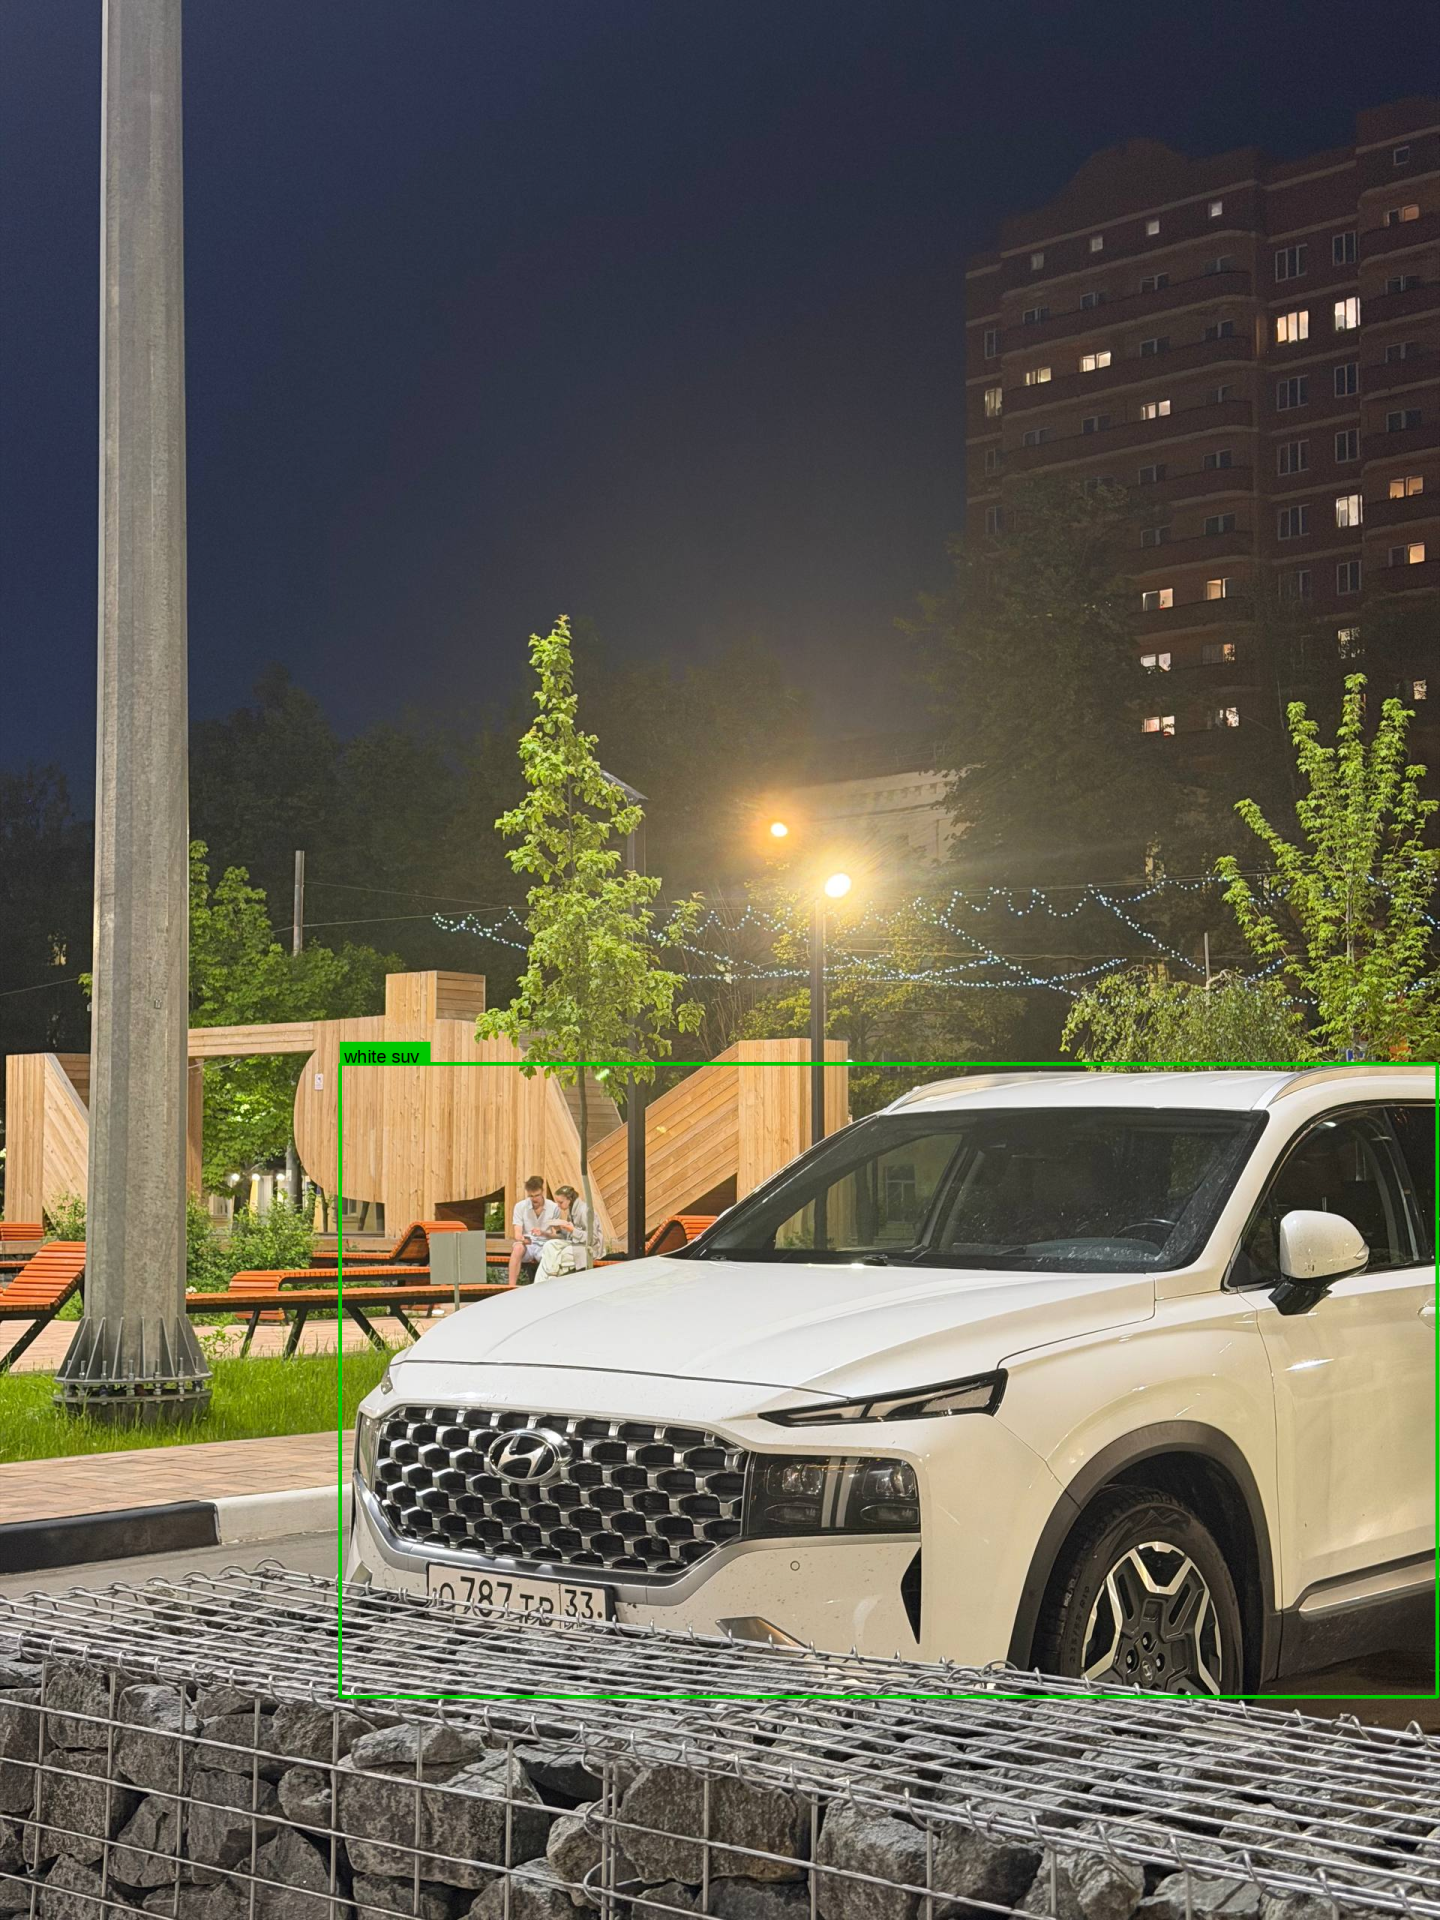

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
IMG_NAME  = 'santafe.jpeg'
IMG_EXTS  = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.heic')

imgs = sorted(p for p in INFER_DIR.iterdir() if p.suffix.lower() in IMG_EXTS)
assert imgs, f'В {INFER_DIR} нет изображений {IMG_EXTS}'
print('Изображения в папке:', [p.name for p in imgs])
TEST_IMG_PATH = str(INFER_DIR / IMG_NAME) if IMG_NAME else str(imgs[0])
print('Выбрано:', TEST_IMG_PATH)

if TEST_IMG_PATH.lower().endswith('.heic'):
    import pillow_heif
    pillow_heif.register_heif_opener()
    frame = cv2.cvtColor(np.array(Image.open(TEST_IMG_PATH).convert('RGB')), cv2.COLOR_RGB2BGR)
else:
    frame = cv2.imread(TEST_IMG_PATH)

result_frame, detected = process_frame(frame)

print(f'Найдено объектов: {len(detected)}')
for v in detected:
    print(f'  {v["class"]:10s}  цвет={v["color"]} ({v["color_conf"]:.2f})  '
          f'кузов={v["body"]} ({v["body_conf"]:.2f})  номер={v["plate"]}')

SHOW_MAX = 1920
h, w = result_frame.shape[:2]
if max(h, w) > SHOW_MAX:
    s = SHOW_MAX / max(h, w)
    result_frame = cv2.resize(result_frame, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)

OUT_SINGLE = OUTPUT_DIR / 'test_single_frame.jpg'
cv2.imwrite(str(OUT_SINGLE), result_frame)
cv2_imshow(result_frame)

if IN_COLAB:
    from google.colab import files
    files.download(str(OUT_SINGLE))


## Инференс по видео

In [16]:
import subprocess, json
VIDEO_NAME = 'IMG_1239.MOV'
VIDEO_EXTS = ('.mp4', '.mov', '.avi', '.mkv', '.webm')

vids = sorted(p for p in INFER_DIR.iterdir() if p.suffix.lower() in VIDEO_EXTS)
assert vids, f'В {INFER_DIR} нет видео {VIDEO_EXTS}'
print('Видео в папке:', [p.name for p in vids])
TEST_VIDEO_PATH = str(INFER_DIR / VIDEO_NAME) if VIDEO_NAME else str(vids[0])
assert Path(TEST_VIDEO_PATH).exists(), f'Файл не найден: {TEST_VIDEO_PATH}'
print('Выбрано:', TEST_VIDEO_PATH)

def _probe(path):
    try:
        out = subprocess.run(
            ['ffprobe', '-v', 'quiet', '-select_streams', 'v:0', '-show_entries',
             'stream=color_transfer,color_primaries,color_space', '-of', 'json', path],
            capture_output=True, text=True).stdout
        return json.loads(out).get('streams', [{}])[0]
    except Exception:
        return {}

_info = _probe(TEST_VIDEO_PATH)
_trc  = (_info.get('color_transfer') or '').lower()
print('Цвет исходника:', _info or 'не определён')

if _trc in ('smpte2084', 'arib-std-b67'):
    print('Обнаружен HDR → конвертирую в SDR BT.709 (иначе пересвет и нечитаемый номер)')
    _sdr = '/content/infer_sdr.mp4'
    _tonemap = ('zscale=t=linear:npl=100,format=gbrpf32le,zscale=p=bt709,'
                'tonemap=tonemap=hable:desat=0,zscale=t=bt709:m=bt709:r=tv,format=yuv420p')
    _r = subprocess.run(['ffmpeg', '-y', '-i', TEST_VIDEO_PATH, '-vf', _tonemap,
                         '-c:v', 'libx264', '-crf', '18', '-preset', 'fast', _sdr],
                        capture_output=True, text=True)
    if Path(_sdr).exists() and Path(_sdr).stat().st_size > 0:
        TEST_VIDEO_PATH = _sdr
        print('SDR-версия готова:', _sdr)
    else:
        print('Не удалось тонмапить (нет zscale?), продолжаю с оригиналом.')
        print(_r.stderr[-400:])
else:
    print('SDR-видео — конвертация не нужна.')

print('Итоговый путь:', TEST_VIDEO_PATH)


Видео в папке: ['IMG_1239.MOV', 'IMG_8427.MOV']
Выбрано: /content/drive/MyDrive/diploma/inference/IMG_1239.MOV
Цвет исходника: {'color_space': 'bt709', 'color_transfer': 'bt709', 'color_primaries': 'bt709'}
SDR-видео — конвертация не нужна.
Итоговый путь: /content/drive/MyDrive/diploma/inference/IMG_1239.MOV


In [17]:
def predict_proba(model, crop_bgr):
    img = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    with torch.no_grad():
        p = torch.softmax(model(INF_TF(img).unsqueeze(0).to(DEVICE)), dim=1)
    return p[0].cpu().numpy()

def laplacian_sharpness(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

_POS_IS_DIGIT = [False, True, True, True, False, False, True, True, True]
_TO_DIGIT  = {'О': '0', 'Б': '6', 'В': '8', 'З': '3', 'Т': '7', 'А': '4', 'У': '4'}
_TO_LETTER = {'0': 'О', '8': 'В', '6': 'Б', '3': 'З', '7': 'Т', '4': 'А'}

def _coerce_ru_plate(raw):
    """Привести строку OCR к формату РФ-номера с учётом позиций символов."""
    s = ''.join(ch for ch in raw if ch.isalnum()).translate(LATIN_TO_CYR)
    if not (8 <= len(s) <= 9):
        return ''
    out = []
    for ch, want_digit in zip(s, _POS_IS_DIGIT[:len(s)]):
        if want_digit and not ch.isdigit():
            ch = _TO_DIGIT.get(ch, ch)
        elif not want_digit and ch.isdigit():
            ch = _TO_LETTER.get(ch, ch)
        out.append(ch)
    m = PLATE_REGEX.search(''.join(out))
    return m.group(0) if m else ''

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

def read_plate_strict(plate_crop, reader, min_width=60):
    """OCR номера → (текст_РФ, conf, raw_ocr). Текст пустой, если даже после
    позиционной коррекции формат РФ не получился. raw_ocr — для диагностики."""
    if plate_crop is None or plate_crop.size == 0:
        return '', 0.0, ''
    h, w = plate_crop.shape[:2]
    if w < min_width:
        return '', 0.0, ''
    scale = max(1, 300 // max(w, 1))
    if scale > 1:
        plate_crop = cv2.resize(plate_crop, (w * scale, h * scale),
                                interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    gray = _clahe.apply(gray)
    result = reader.readtext(gray, detail=1, allowlist=_PLATE_ALLOWLIST)
    if not result:
        return '', 0.0, ''
    result.sort(key=lambda r: (r[0][0][0] + r[0][2][0]) / 2)
    raw  = ''.join(r[1] for r in result).upper().replace(' ', '').translate(LATIN_TO_CYR)
    conf = float(np.mean([r[2] for r in result]))
    m = PLATE_REGEX.search(raw)
    if m:
        return m.group(0), conf, raw
    fixed = _coerce_ru_plate(raw)
    if fixed:
        return fixed, conf, raw
    return '', 0.0, raw


Helper-функции трекинг-инференса определены.


In [18]:
from collections import defaultdict, Counter

TRACK_CONF       = 0.4
MIN_COLOR_BOX    = 80
MIN_PLATE_W      = 60
MIN_BODY_BOX     = 128
BODY_CONF_MIN    = 0.45
MAX_OCR_PER_ID   = 20
MIN_TRACK_FRAMES = 5

try:
    vehicle_model.predictor.trackers[0].reset()
except Exception:
    pass

tracks = defaultdict(lambda: {
    'color_prob': np.zeros(len(COLOR_LABELS)), 'color_n': 0,
    'color_best_conf': 0.0, 'color_best_lbl': '',
    'body_prob':  np.zeros(len(BODY_LABELS)),  'body_n': 0,
    'plates': [], 'raw_ocr': [], 'ocr_tries': 0,
    'best_crop': None, 'best_plate_crop': None, 'best_plate_w': 0, 'best_sharp': -1.0,
    'cls': 'vehicle', 'n': 0,
})

cap   = cv2.VideoCapture(TEST_VIDEO_PATH)
vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Видео: {vid_w}×{vid_h}, {total} кадров')

fidx, t0 = 0, time.time()
while True:
    ret, frame = cap.read()
    if not ret:
        break
    res   = vehicle_model.track(frame, persist=True, tracker='bytetrack.yaml',
                                conf=TRACK_CONF, classes=list(VEHICLE_CLASSES), verbose=False)
    boxes = res[0].boxes
    if boxes is not None and boxes.id is not None:
        for box in boxes:
            tid = int(box.id[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            T = tracks[tid]
            T['n']   += 1
            T['cls']  = VEHICLE_CLASSES.get(int(box.cls[0]), 'vehicle')
            side      = max(x2 - x1, y2 - y1)
            if side >= MIN_COLOR_BOX:
                cp = predict_proba(color_model, crop)
                ci = int(cp.argmax())
                T['color_prob'] += cp * cp[ci]
                T['color_n']    += 1
                if cp[ci] > T['color_best_conf']:
                    T['color_best_conf'] = float(cp[ci])
                    T['color_best_lbl']  = COLOR_LABELS[ci]
            if side >= MIN_BODY_BOX:
                T['body_prob'] += predict_proba(body_model, crop)
                T['body_n']    += 1
            s = laplacian_sharpness(crop)
            if s > T['best_sharp']:
                T['best_sharp'] = s
                T['best_crop']  = crop.copy()
            pcrop = detect_plate(crop, plate_model)
            if pcrop is not None and pcrop.shape[1] > T['best_plate_w']:
                T['best_plate_w']    = pcrop.shape[1]
                T['best_plate_crop'] = pcrop.copy()
            if (pcrop is not None and pcrop.shape[1] >= MIN_PLATE_W
                    and T['ocr_tries'] < MAX_OCR_PER_ID):
                T['ocr_tries'] += 1
                txt, conf, raw = read_plate_strict(pcrop, ocr_reader, MIN_PLATE_W)
                if txt:
                    T['plates'].append((txt, conf))
                elif raw:
                    T['raw_ocr'].append(raw)
    fidx += 1
    if fidx % 60 == 0:
        print(f'  Кадр {fidx}/{total}  активных треков={len(tracks)}')
cap.release()
print(f'Готово за {time.time()-t0:.1f}s. Всего треков: {len(tracks)}')

def agg_color(T):
    if T['color_n'] > 0:
        cprob = T['color_prob'] / T['color_prob'].sum()
        ci    = int(cprob.argmax())
        return COLOR_LABELS[ci], float(cprob[ci]), False
    if T['best_crop'] is not None:
        cp = predict_proba(color_model, T['best_crop']); ci = int(cp.argmax())
        return COLOR_LABELS[ci], float(cp[ci]), True
    return '?', 0.0, True

rows = []
for tid, T in sorted(tracks.items()):
    if T['n'] < MIN_TRACK_FRAMES:
        continue
    color, color_conf, color_fallback = agg_color(T)
    T['color'], T['color_conf'] = color, color_conf
    color_info = f"{color} ({color_conf:.2f})"
    if color_fallback:
        color_info += ' [по лучшему кадру]'
    elif T['color_best_lbl'] and T['color_best_lbl'] != color:
        color_info += f"; лучший кадр: {T['color_best_lbl']} {T['color_best_conf']:.2f}"
    if T['body_n'] > 0:
        bp    = T['body_prob'] / T['body_n']
        order = bp.argsort()[::-1]
        body_top1 = f"{BODY_LABELS[order[0]]} ({bp[order[0]]:.2f})"
        if bp[order[0]] < BODY_CONF_MIN:
            body_top1 += ' ⚠'
        body_top3 = ', '.join(f"{BODY_LABELS[i]} {bp[i]:.2f}" for i in order[:3])
    else:
        body_top1, body_top3 = 'n/a (мелкий)', '—'
    if T['plates']:
        cnt        = Counter(t for t, _ in T['plates'])
        plate      = cnt.most_common(1)[0][0]
        plate_info = f"{plate}  (×{cnt[plate]} из {len(T['plates'])})"
    else:
        plate      = ''
        raw_sample = Counter(T['raw_ocr']).most_common(1)
        plate_info = f"нет | OCR читал: «{raw_sample[0][0]}»" if raw_sample else '—'
    rows.append({'id': tid, 'class': T['cls'], 'frames': T['n'],
                 'color': color, 'color_info': color_info,
                 'body_top1': body_top1, 'body_top3': body_top3,
                 'plate': plate, 'plate_px': T['best_plate_w'], 'plate_info': plate_info})

df_tracks = pd.DataFrame(rows)
n_valid = int((df_tracks['plate'] != '').sum()) if len(df_tracks) else 0
print(f'\nМашин после фильтра (≥{MIN_TRACK_FRAMES} кадров): {len(df_tracks)}')
print(f'С валидным номером (regex РФ): {n_valid}')
if len(df_tracks):
    print(f'Макс. ширина номера среди всех машин: {df_tracks["plate_px"].max()} px '
          f'(для надёжного OCR нужно ≳ {MIN_PLATE_W}-100 px)')
df_tracks[['id', 'class', 'frames', 'color_info', 'body_top1', 'plate', 'plate_px', 'plate_info']]


Видео: 1280×720, 359 кадров — полное разрешение (номер не теряет пиксели)
  Кадр 60/359  активных треков=5
  Кадр 120/359  активных треков=6
  Кадр 180/359  активных треков=10
  Кадр 240/359  активных треков=14
  Кадр 300/359  активных треков=19
Готово за 33.9s. Всего треков: 22

Машин после фильтра (≥5 кадров): 14
С валидным номером (regex РФ): 2
Макс. ширина номера среди всех машин: 126 px (для надёжного OCR нужно ≳ 60-100 px)


,id,class,frames,color_info,body_top1,plate,plate_px,plate_info
0,1,car,183,white (0.76),sedan (0.44) ⚠,,14,—
1,2,car,15,brown (0.59) [по лучшему кадру],n/a (мелкий),,0,—
2,3,car,197,white (0.55),suv (0.34) ⚠,В431УЕ169,126,В431УЕ169 (×2 из 3)
3,8,car,13,silver (0.84),n/a (мелкий),,8,—
4,11,car,7,brown (0.77) [по лучшему кадру],n/a (мелкий),,0,—
5,12,car,125,black (0.85),suv (0.62),А356КН550,106,А356КН550 (×4 из 10)
6,15,car,7,silver (0.56),n/a (мелкий),,5,—
7,16,car,60,white (0.68),sedan (0.45) ⚠,,7,—
8,17,car,15,brown (0.46),n/a (мелкий),,7,—
9,23,car,16,black (0.37) [по лучшему кадру],n/a (мелкий),,0,—


Машин в галерее: 14


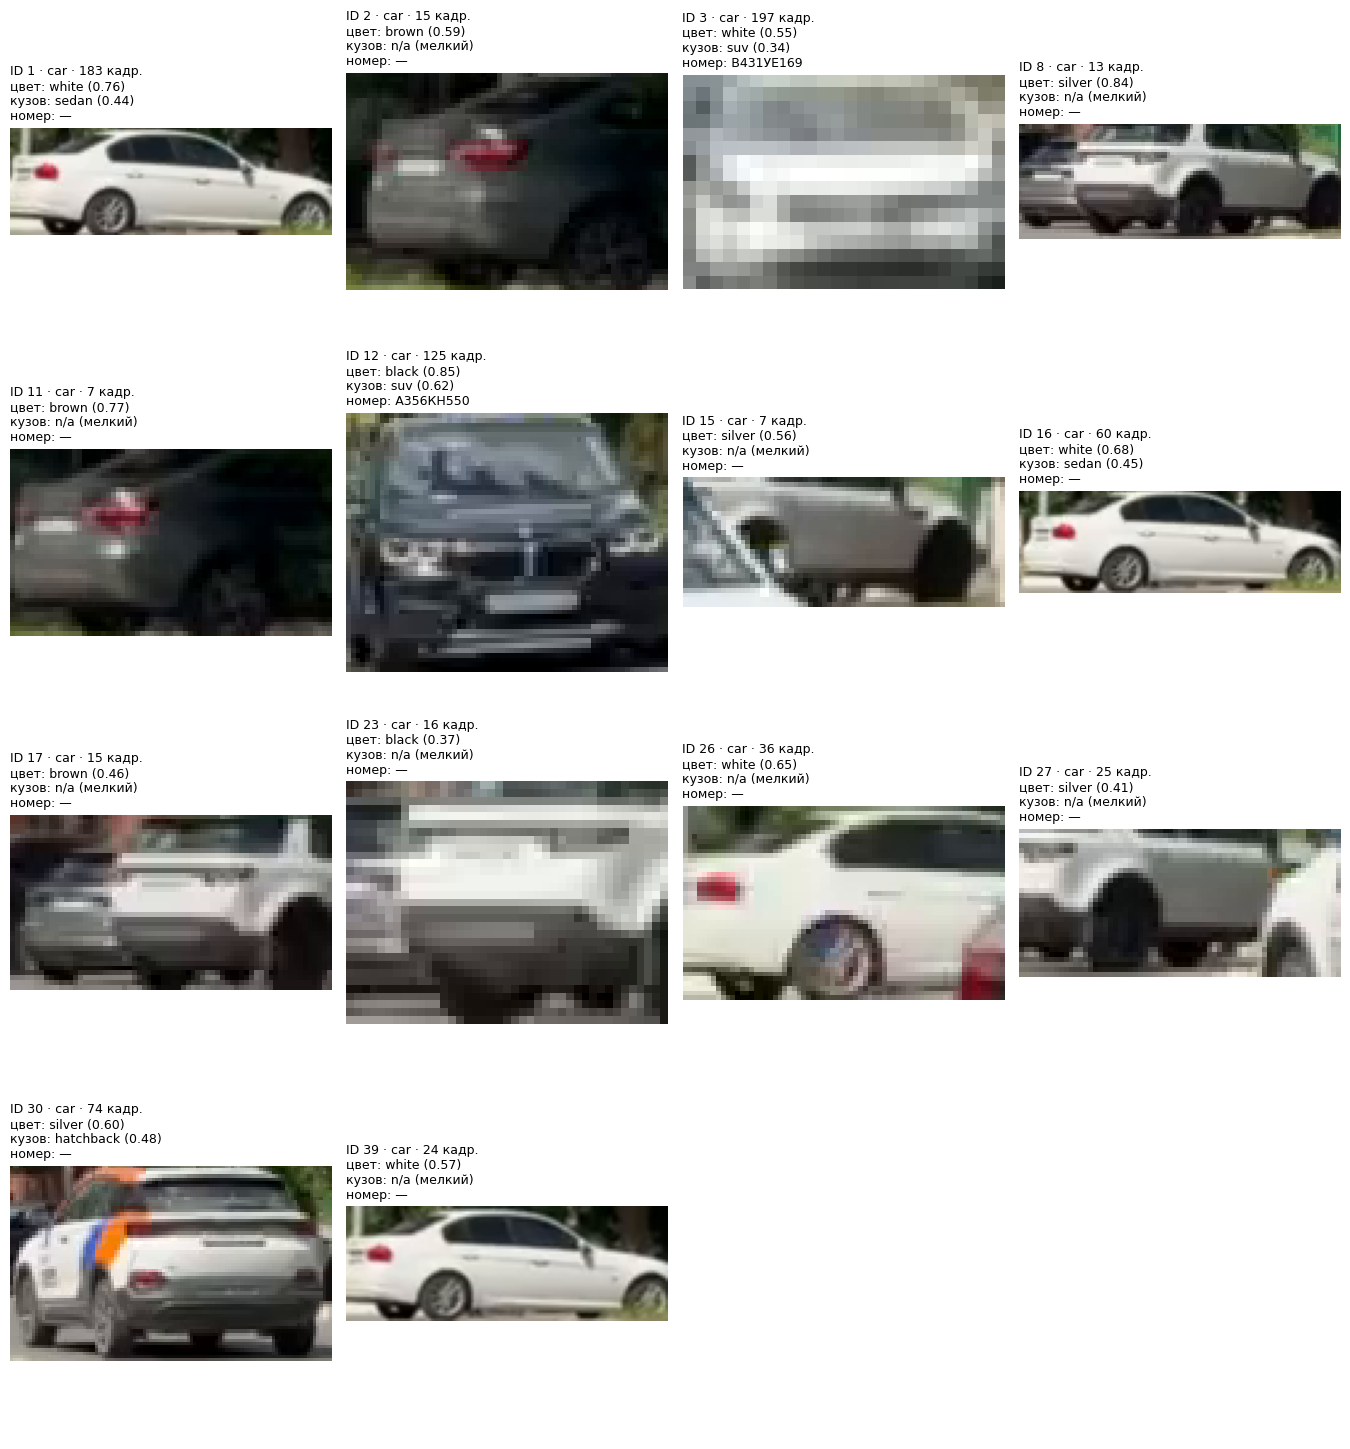

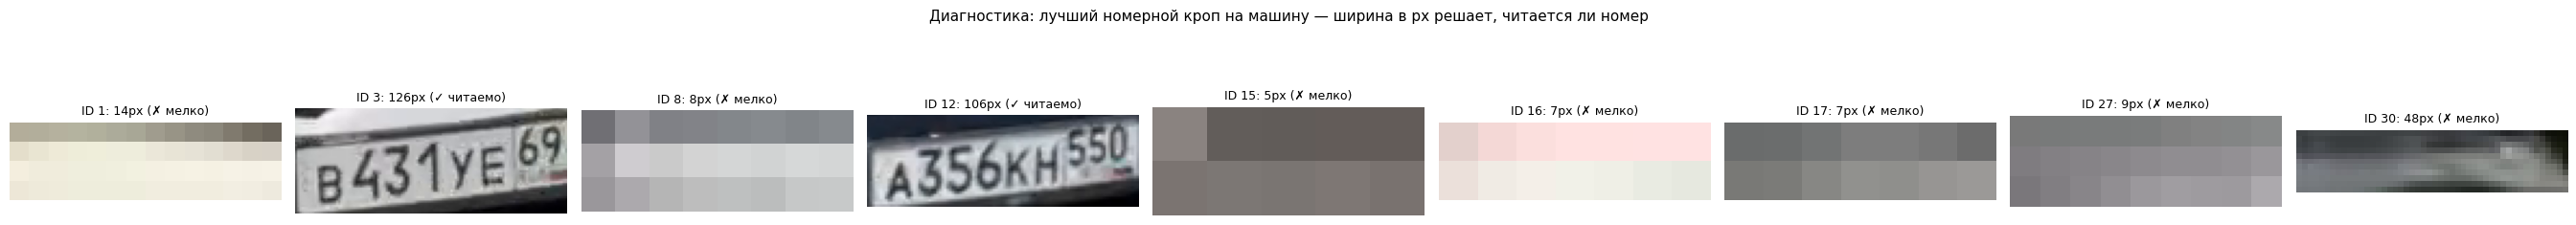

In [19]:
import math

items = [(tid, T) for tid, T in sorted(tracks.items())
         if T['n'] >= MIN_TRACK_FRAMES and T['best_crop'] is not None]
print(f'Машин в галерее: {len(items)}')

if items:
    cols   = 4
    rows_n = math.ceil(len(items) / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.4, rows_n * 3.7))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (tid, T) in zip(axes, items):
        color = f"{T.get('color', '?')} ({T.get('color_conf', 0):.2f})"
        if T['body_n'] > 0:
            bp = T['body_prob'] / T['body_n']; bi = int(bp.argmax())
            body = f"{BODY_LABELS[bi]} ({bp[bi]:.2f})"
        else:
            body = 'n/a (мелкий)'
        plate = Counter(t for t, _ in T['plates']).most_common(1)[0][0] if T['plates'] else '—'
        ax.imshow(cv2.cvtColor(T['best_crop'], cv2.COLOR_BGR2RGB))
        ax.set_title(f"ID {tid} · {T['cls']} · {T['n']} кадр.\n"
                     f"цвет: {color}\nкузов: {body}\nномер: {plate}",
                     fontsize=9, loc='left')
    plt.tight_layout()
    plt.show()

    pcs = [(tid, T['best_plate_crop'], T['best_plate_w'])
           for tid, T in items if T['best_plate_crop'] is not None]
    if pcs:
        fig, axes = plt.subplots(1, len(pcs), figsize=(len(pcs) * 3, 3))
        axes = np.atleast_1d(axes)
        for ax, (tid, crop, w) in zip(axes, pcs):
            ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); ax.axis('off')
            ok = '✓ читаемо' if w >= MIN_PLATE_W else '✗ мелко'
            ax.set_title(f'ID {tid}: {w}px ({ok})', fontsize=9)
        plt.suptitle('Диагностика: лучший номерной кроп на машину — ширина в px '
                     'решает, читается ли номер', fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print('Номерных кропов не нашлось — детектор номеров ничего не выделил.')


## Сохраняем размеченное видео

In [20]:
import subprocess, os
OUT_VIDEO_H264 = OUTPUT_DIR / 'output_video_h264.mp4'
OUT_MAX_SIDE   = 1920

def track_caption(tid):
    T = tracks.get(tid)
    if T is None:
        return ''
    color = T.get('color', '?')
    body  = BODY_LABELS[int((T['body_prob'] / T['body_n']).argmax())] if T['body_n'] > 0 else '?'
    plate = Counter(t for t, _ in T['plates']).most_common(1)[0][0] if T['plates'] else ''
    return f'{color} {body} {plate}'.strip()

try:
    vehicle_model.predictor.trackers[0].reset()
except Exception:
    pass

cap    = cv2.VideoCapture(TEST_VIDEO_PATH)
w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_in = cap.get(cv2.CAP_PROP_FPS)
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if not (5 <= fps_in <= 240):
    fps_in = 30.0
    print(f'FPS не определён из файла, используем {fps_in}')
else:
    print(f'FPS: {fps_in:.2f}')

out_scale = min(1.0, OUT_MAX_SIDE / max(w, h))
out_w     = int(w * out_scale)
out_h     = int(h * out_scale)
if out_scale < 1.0:
    print(f'Выход ужимаем: {w}×{h} → {out_w}×{out_h} (детекция на полном разрешении)')

ffmpeg_proc = subprocess.Popen([
    'ffmpeg', '-y',
    '-f', 'rawvideo', '-vcodec', 'rawvideo',
    '-s', f'{out_w}x{out_h}', '-pix_fmt', 'bgr24', '-r', str(fps_in),
    '-i', 'pipe:0',
    '-vf', 'scale=in_range=full:out_range=tv',
    '-c:v', 'libx264', '-crf', '20', '-preset', 'fast', '-pix_fmt', 'yuv420p',
    '-color_primaries', 'bt709', '-color_trc', 'bt709', '-colorspace', 'bt709',
    '-color_range', 'tv', '-movflags', '+faststart',
    str(OUT_VIDEO_H264)
], stdin=subprocess.PIPE)

t0, n = time.time(), 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    res    = vehicle_model.track(frame, persist=True, tracker='bytetrack.yaml',
                                 conf=TRACK_CONF, classes=list(VEHICLE_CLASSES), verbose=False)
    boxes  = res[0].boxes
    canvas = frame.copy()
    if boxes is not None and boxes.id is not None:
        thick = box_thickness(canvas.shape[1])
        for box in boxes:
            tid = int(box.id[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 200, 0), thick)
            canvas = _draw_label_pil(canvas, x1, y1, track_caption(tid))
    if out_scale < 1.0:
        canvas = cv2.resize(canvas, (out_w, out_h), interpolation=cv2.INTER_AREA)
    ffmpeg_proc.stdin.write(canvas.tobytes())
    n += 1
    if n % 60 == 0:
        print(f'  Кадр {n}/{total}')

cap.release()
ffmpeg_proc.stdin.close()
ffmpeg_proc.wait()

sz = os.path.getsize(OUT_VIDEO_H264) / 1e6
print(f'Готово за {time.time()-t0:.1f}s  |  {n} кадров  |  H.264: {sz:.0f} MB')
print(f'Файл: {OUT_VIDEO_H264}')

if IN_COLAB:
    from google.colab import files
    files.download(str(OUT_VIDEO_H264))


FPS: 30.00
  Кадр 60/359
  Кадр 120/359
  Кадр 180/359
  Кадр 240/359
  Кадр 300/359
Готово за 29.6s  |  359 кадров  |  H.264: 7 MB
Файл: diploma_04_pipeline/output/output_video_h264.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>